In [2]:
# ---- Setup & imports ----
import sys
from pathlib import Path

# Make the package importable from this notebook's location
proj_dir = Path('../..').resolve()
if str(proj_dir) not in sys.path:
    sys.path.insert(0, str(proj_dir))

# Auto-reload modules when source files change (no kernel restart needed)
%load_ext autoreload
%autoreload 2

import AMFOrA_public
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

print(f"AMFOrA_public loaded from: {AMFOrA_public.__file__}")
print(f"Version: {AMFOrA_public.__version__}")

AMFOrA_public loaded from: /Users/aiacobucci922/Documents/Python/AMACFA+/AMFOrA_public/__init__.py
Version: 0.2.0


In [3]:
# --- EDIT THESE ---
IMAGE_DIR    = "/Users/aiacobucci922/Documents/Ceramic Project Raw Data/AMFOrA_Test_Bars/prepared"   # folder with multiple sherd scans
SCAN_DPI     = 1200                              # scanner resolution


In [4]:
# full_analysis -- comprehensive batch analysis of all images in a directory
test_bars_full = AMFOrA_public.full_analysis(IMAGE_DIR, scan_dpi=SCAN_DPI, analyze_core_periphery=True, save_csv=True, output_filename="test_bars_full_analysis.csv")
display(test_bars_full)

Starting full analysis of 150 ceramic sherds...
Using scan DPI: 1200
Detection methods: Blob + Contour
Analyzing inclusions: True
Analyzing voids: True
--------------------------------------------------
Processing R14G_2.jpeg (1/150)
  Success - Blob: 44 inclusions, Contour: 84 inclusions
Processing R04G_2.jpeg (2/150)
  Success - Blob: 39 inclusions, Contour: 35 inclusions
Processing R04TC_2.jpeg (3/150)
  Success - Blob: 53 inclusions, Contour: 50 inclusions
Processing R05TC_2.jpeg (4/150)
  Success - Blob: 97 inclusions, Contour: 74 inclusions
Processing R07G_4.jpeg (5/150)
  Success - Blob: 114 inclusions, Contour: 96 inclusions
Processing R02TC_5.jpeg (6/150)
  Success - Blob: 57 inclusions, Contour: 40 inclusions
Processing R11G_1.jpeg (7/150)
  Success - Blob: 35 inclusions, Contour: 95 inclusions
Processing R01G_1.jpeg (8/150)
  Success - Blob: 4 inclusions, Contour: 4 inclusions
Processing R03TC_5.jpeg (9/150)
  Success - Blob: 36 inclusions, Contour: 52 inclusions
Processing 

,filename,file_path,scan_dpi,analysis_status,sherd_area_cm2,blob_inclusion_count,blob_inclusion_total_area_cm2,blob_inclusion_mean_area_cm2,blob_inclusion_std_area_cm2,blob_inclusion_min_area_cm2,...,inner_margin_color_b,outer_margin_color_l,outer_margin_color_a,outer_margin_color_b,core_atmosphere,inner_margin_atmosphere,outer_margin_atmosphere,core_periphery_gradient,firing_interpretation,margin_symmetry
0,R14G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.556370,44,0.072211,0.001641,0.001921,0.000330,...,134.0,191.0,132.0,135.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,25.019992,incomplete_oxidation,symmetric
1,R04G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.488601,39,0.073672,0.001889,0.005139,0.000289,...,133.0,205.0,132.0,136.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,18.275667,incomplete_oxidation,symmetric
2,R04TC_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.614443,53,0.071131,0.001342,0.001502,0.000372,...,151.0,137.0,148.0,149.0,oxidized,oxidized,oxidized,6.000000,fully_oxidized,symmetric
3,R05TC_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.562064,97,0.123181,0.001270,0.001386,0.000379,...,149.0,139.0,148.0,148.0,oxidized,oxidized,oxidized,7.141428,fully_oxidized,symmetric
4,R07G_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.530617,114,0.213445,0.001872,0.003694,0.000346,...,132.0,162.0,134.0,136.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,54.120237,incomplete_oxidation,symmetric
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,R11G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.572781,41,0.068041,0.001660,0.002267,0.000269,...,136.0,215.0,131.0,133.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,9.695360,incomplete_oxidation,symmetric
146,R11TC_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.499990,44,0.136642,0.003106,0.005306,0.000503,...,148.0,126.0,144.0,146.0,oxidized,oxidized,oxidized,17.029386,fully_oxidized,symmetric
147,R10TC_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.523430,37,0.099334,0.002685,0.003093,0.000323,...,149.0,144.0,147.0,148.0,oxidized,oxidized,oxidized,10.246951,fully_oxidized,symmetric
148,R12G_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.561365,83,0.148755,0.001792,0.003084,0.000267,...,134.0,214.0,133.0,136.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,12.165525,incomplete_oxidation,symmetric


## User Input

Edit the three variables below to point at your own data.

In [57]:
# --- EDIT THESE ---

SINGLE_IMAGE = "/Users/aiacobucci922/Documents/Ceramic Project Raw Data/AMFOrA_Test_Bars/prepared/R13G_3.jpeg"         # one sherd scan

SCAN_DPI     = 1200                              # scanner resolution
def imshow_cm(ax, image, dpi=SCAN_DPI, cmap=None, **kwargs):
    """Display image with axes in centimeters."""
    h, w = image.shape[:2]
    extent = [0, w / dpi * 2.54, h / dpi * 2.54, 0]
    ax.imshow(image, extent=extent, cmap=cmap, **kwargs)
    ax.set_xlabel("cm")
    ax.set_ylabel("cm")

def imshow_mm(ax, image, dpi=SCAN_DPI, cmap=None, **kwargs):
    """Display image with axes in millimeters."""
    h, w = image.shape[:2]
    extent = [0, w / dpi * 25.4, h / dpi * 25.4, 0]
    ax.imshow(image, extent=extent, cmap=cmap, **kwargs)
    ax.set_xlabel("mm")
    ax.set_ylabel("mm")

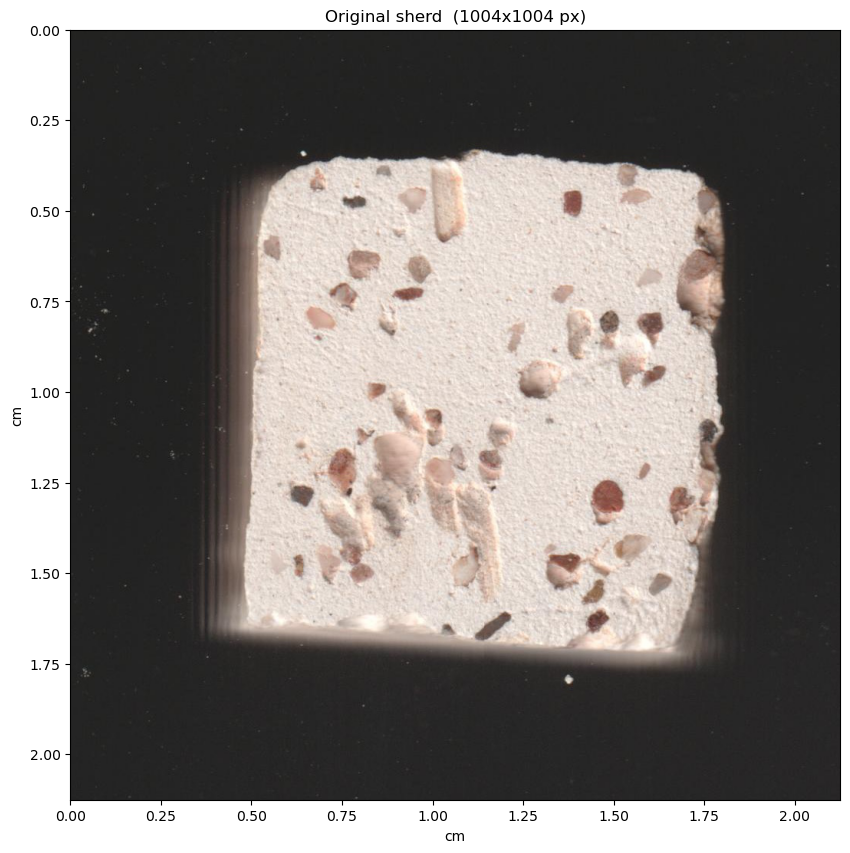

In [58]:
# Load and display the single image
img = cv2.imread(SINGLE_IMAGE)
assert img is not None, f"Could not load image: {SINGLE_IMAGE}"

plt.figure(figsize=(12, 10))
imshow_cm(plt.gca(), img[:, :, ::-1])
plt.title(f"Original sherd  ({img.shape[1]}x{img.shape[0]} px)")
plt.show()

---
## Detection (`core/detection`)

Auto-crop bounds: rows 31:955, cols 61:985  (924 x 924 px  vs original 1004 x 1004)


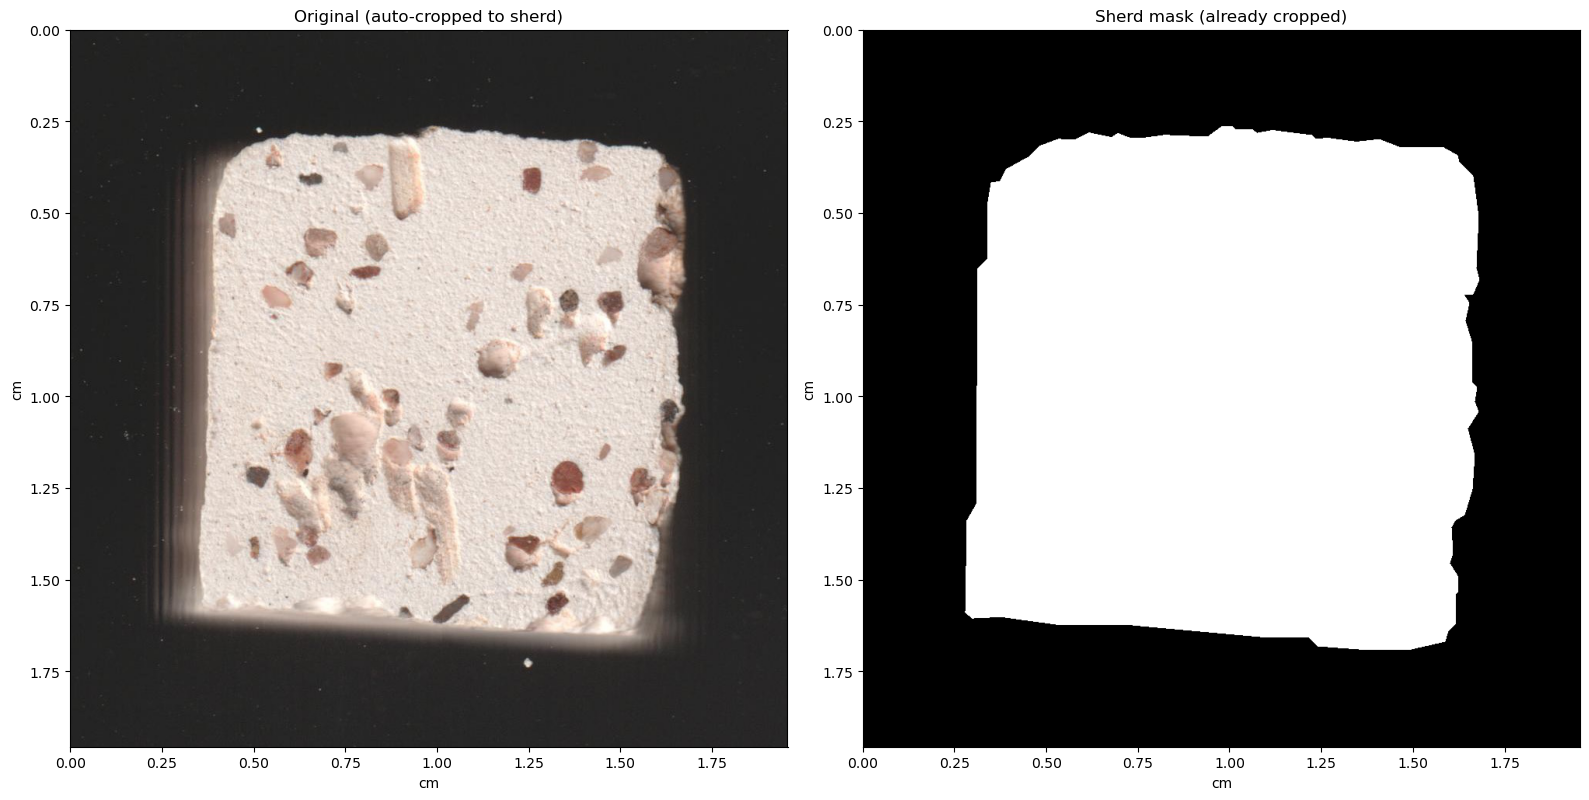

In [59]:
# sherd_mask -- create a binary mask that isolates the sherd from the background
# Returns (mask, crop, sherd_contour) where crop=(y1, y2, x1, x2, pad_top, pad_bottom, pad_left, pad_right)
# in original image coordinates. Extra padding values are >0 when the sherd is near the scan edge.
# The mask is already cropped to the sherd bounding box + 75 px buffer.
# Pass auto_crop=False to get a full-size mask matching the original scan dimensions.
mask, crop, sherd_contour = AMFOrA_public.sherd_mask(img, scan_dpi=SCAN_DPI)
y1, y2, x1, x2 = crop[:4]
print(f"Auto-crop bounds: rows {y1}:{y2}, cols {x1}:{x2}  "
      f"({y2-y1} x {x2-x1} px  vs original {img.shape[0]} x {img.shape[1]})")

# For display, pad the cropped original to match the (possibly padded) mask dimensions
import numpy as np
_img_crop = img[y1:y2, x1:x2]
if len(crop) == 8:
    _pt, _pb, _pl, _pr = crop[4:]
    if _pt or _pb or _pl or _pr:
        _img_crop = np.pad(_img_crop, ((_pt, _pb), (_pl, _pr), (0, 0)),
                           mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
imshow_cm(axes[0], _img_crop[:, :, ::-1])
axes[0].set_title("Original (auto-cropped to sherd)")
imshow_cm(axes[1], mask, cmap="gray")
axes[1].set_title("Sherd mask (already cropped)")
plt.tight_layout()
plt.show()

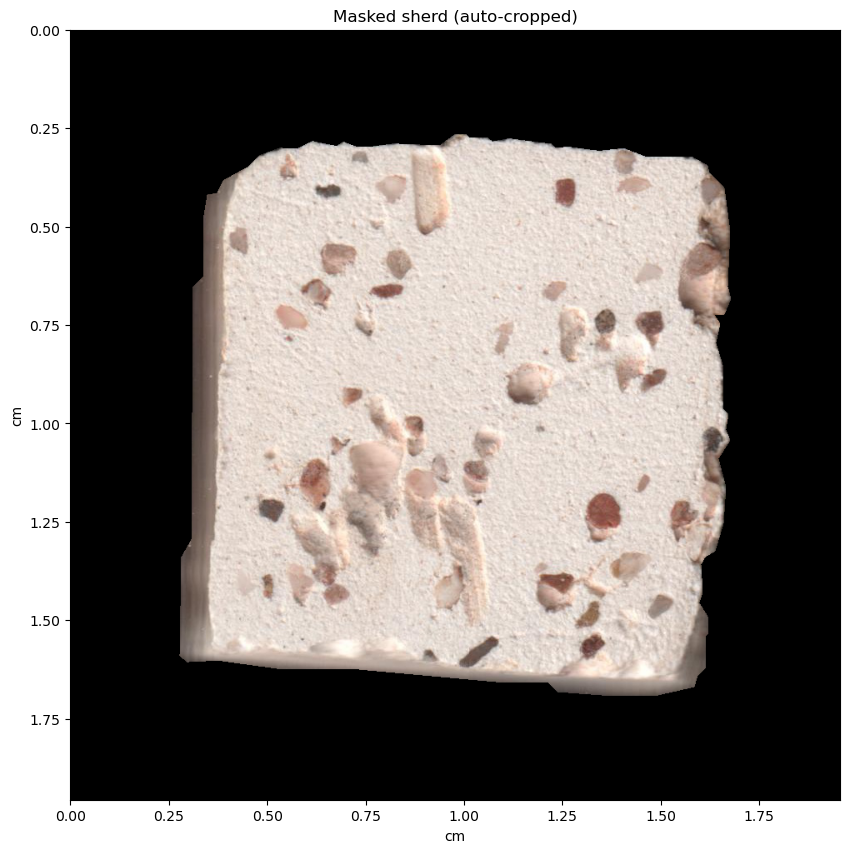

In [60]:
# apply_mask -- crop the original image to the sherd region and apply the mask.
# After this call masked_img is already at the cropped size; no further slicing needed.
masked_img = AMFOrA_public.apply_mask(img, mask, crop)

plt.figure(figsize=(12, 10))
imshow_cm(plt.gca(), masked_img[:, :, ::-1])
plt.title("Masked sherd (auto-cropped)")
plt.show()


Inclusions detected: 53
Voids detected:      5


Text(0.5, 1.0, 'Inclusions (green): 53  |  Voids (red): 5')

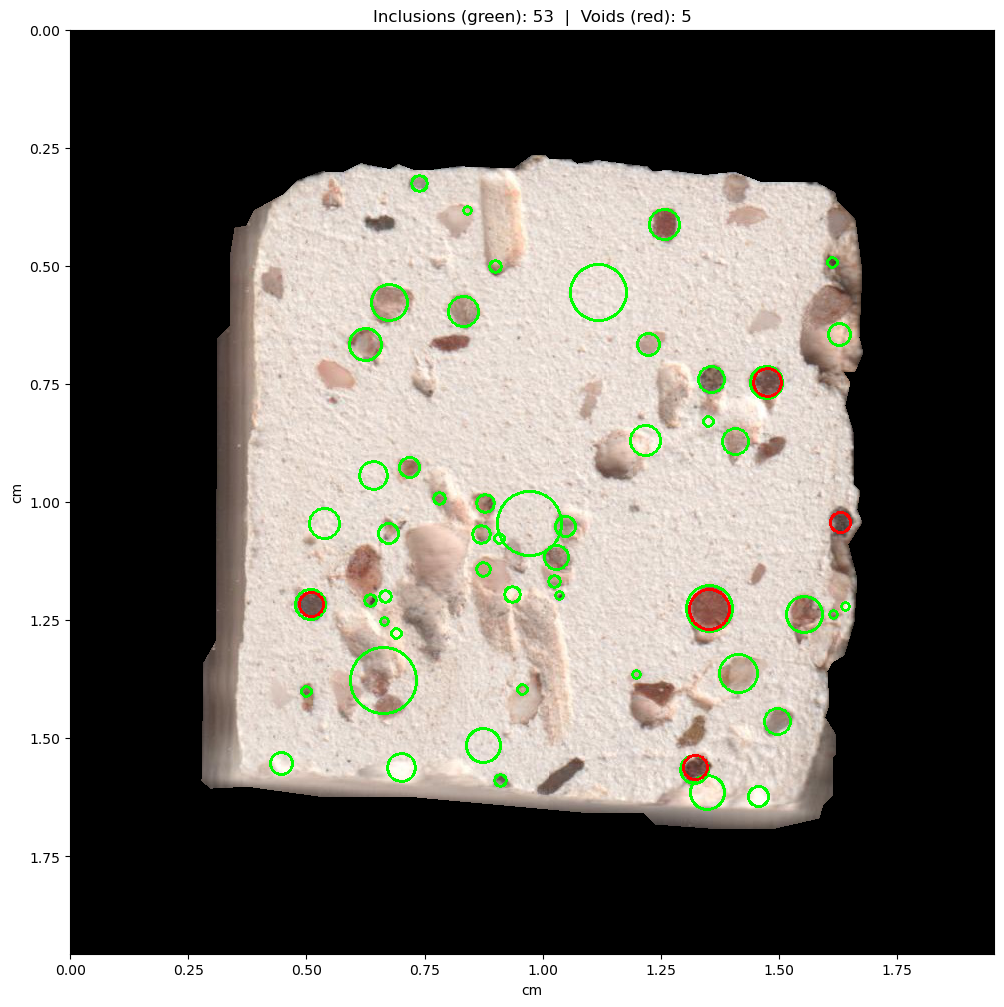

In [61]:
# sherd_blobs -- detect inclusions (light blobs) and voids (dark blobs)
inclusion_blobs, void_blobs = AMFOrA_public.sherd_blobs(masked_img, scan_dpi=SCAN_DPI)
print(f"Inclusions detected: {len(inclusion_blobs)}")
print(f"Voids detected:      {len(void_blobs)}")

# Overlay blob circles on the masked image
overlay = masked_img.copy()
for kp in inclusion_blobs:
    x, y = map(int, kp.pt)
    r = max(1, int(kp.size / 2))
    cv2.circle(overlay, (x, y), r, (0, 255, 0), 2)
for kp in void_blobs:
    x, y = map(int, kp.pt)
    r = max(1, int(kp.size / 2))
    cv2.circle(overlay, (x, y), r, (0, 0, 255), 2)

plt.figure(figsize=(14, 12))
imshow_cm(plt.gca(), overlay[:, :, ::-1])
plt.title(f"Inclusions (green): {len(inclusion_blobs)}  |  Voids (red): {len(void_blobs)}")

Contour inclusions: 96
Contour voids:      1


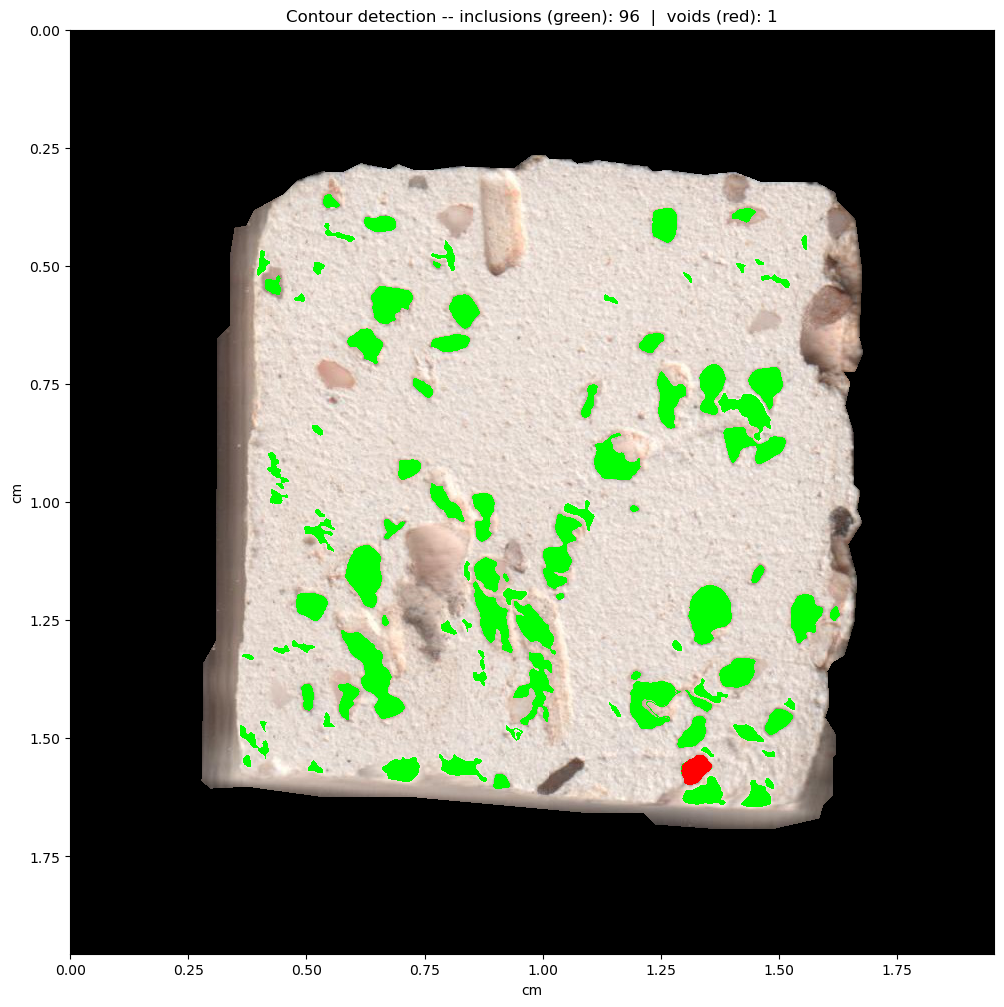

In [62]:
# contour_detection -- contour-based feature detection (better for angular/irregular shapes)
contour_results = AMFOrA_public.contour_detection(masked_img, scan_dpi=SCAN_DPI)

print(f"Contour inclusions: {contour_results['total_inclusions']}")
print(f"Contour voids:      {contour_results['total_voids']}")

# Draw contours on the masked image
contour_img = masked_img.copy()
cv2.drawContours(contour_img, contour_results['inclusions'], -1, (0, 255, 0), -1)
cv2.drawContours(contour_img, contour_results['voids'], -1, (0, 0, 255), -1)

plt.figure(figsize=(14, 12))
imshow_cm(plt.gca(), contour_img[:, :, ::-1])
plt.title(f"Contour detection -- inclusions (green): {contour_results['total_inclusions']}  |  voids (red): {contour_results['total_voids']}")
plt.show()


In [63]:
test_bars_full.sort_values("contour_inclusion_count", ascending = True, inplace=True)

In [56]:
test_bars_full.head(25)

,filename,file_path,scan_dpi,analysis_status,sherd_area_cm2,blob_inclusion_count,blob_inclusion_total_area_cm2,blob_inclusion_mean_area_cm2,blob_inclusion_std_area_cm2,blob_inclusion_min_area_cm2,...,inner_margin_color_b,outer_margin_color_l,outer_margin_color_a,outer_margin_color_b,core_atmosphere,inner_margin_atmosphere,outer_margin_atmosphere,core_periphery_gradient,firing_interpretation,margin_symmetry
120,R01G_3.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.559743,1,0.000785,0.000785,0.000000,0.000785,...,136.0,220.0,131.0,133.0,reduced,incomplete_oxidation,incomplete_oxidation,13.000000,sandwich_oxidized_margins,symmetric
144,R01G_2.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.524573,4,0.002254,0.000563,0.000144,0.000385,...,133.0,222.0,131.0,134.0,incomplete_oxidation,reduced,incomplete_oxidation,8.124038,differential_margins,asymmetric
7,R01G_1.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.566092,4,0.010526,0.002632,0.003572,0.000473,...,135.0,203.0,133.0,134.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,19.104973,incomplete_oxidation,symmetric
102,R01G_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.522767,4,0.071768,0.017942,0.019041,0.000403,...,134.0,197.0,133.0,136.0,reduced,incomplete_oxidation,incomplete_oxidation,30.215890,sandwich_oxidized_margins,symmetric
23,R01TC_1.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.775165,2,0.002093,0.001046,0.000358,0.000688,...,142.0,128.0,150.0,149.0,oxidized,oxidized,oxidized,46.421978,fully_oxidized,symmetric
81,R01TC_4.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.469945,5,0.046458,0.009292,0.014650,0.000587,...,149.0,138.0,151.0,152.0,oxidized,oxidized,oxidized,14.628739,fully_oxidized,symmetric
112,R01TC_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.697772,4,0.019943,0.004986,0.004935,0.001358,...,145.0,128.0,150.0,150.0,oxidized,oxidized,oxidized,28.301943,fully_oxidized,symmetric
93,R01G_5.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.492100,8,0.007450,0.000931,0.000720,0.000504,...,135.0,218.0,132.0,136.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,6.708204,incomplete_oxidation,symmetric
135,R01TC_3.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.657669,8,0.014217,0.001777,0.001869,0.000539,...,150.0,136.0,147.0,147.0,oxidized,oxidized,oxidized,9.110434,fully_oxidized,symmetric
57,R02G_1.jpeg,/Users/aiacobucci922/Documents/Ceramic Project...,1200,success,1.644932,7,0.020275,0.002896,0.002838,0.000514,...,135.0,222.0,131.0,133.0,incomplete_oxidation,incomplete_oxidation,incomplete_oxidation,72.090221,incomplete_oxidation,symmetric
